# Step 6 — Simulated box pickup

Connect the existing ANN to the simulated robot: **predict an approach → move the arm → check contact → attach the box → lift it**. The frozen ANN, scalers, IK policy, and validated FK remain unchanged.

This first pickup demonstration uses an **ideal point gripper** and a 1 cm square box. A hand within 0.5 cm of the box center can attach. No fingers, forces, table, obstacles, collision checks, or grasp orientation are modeled yet. The robot moves by interpolating its joint angles for animation; this can make a curved Cartesian path and is not trajectory planning. Step 7 and Step 8 will address planning and fuller manipulation behavior.

Open this notebook from the repository root with the Step 4 environment (`requirements/requirements-ann.txt`). Existing training and evaluation notebooks do not need to be executed.

## 6.1 Reuse the robot and learned IK pipeline

`python/robot_pipeline.py` loads the saved model/scalers, reads the original `RobotArm2DOF` class from the mathematical notebook, and reuses the Step 5 `predict_angles` function. Only those definitions are loaded: no training, dataset generation, or full test evaluation runs.

`python/pickup_simulation.py` handles simulation states separately from drawing. It rejects invalid predicted angles before motion and leaves a missed box at its original position. The result contains fixed frames, so replaying an animation cannot change whether a pickup succeeded.

In [1]:
# Repository setup: run this cell first from the root or notebooks/ folder.
from pathlib import Path
import os
import sys

REPOSITORY_ROOT = Path.cwd().resolve()
if not (REPOSITORY_ROOT / "notebooks/forward_kinematics.ipynb").is_file():
    REPOSITORY_ROOT = REPOSITORY_ROOT.parent
if not (REPOSITORY_ROOT / "notebooks/forward_kinematics.ipynb").is_file():
    raise FileNotFoundError("Open the notebook from the repository root or notebooks/ folder.")
os.chdir(REPOSITORY_ROOT)  # Existing data/, models/, and report paths stay repo-relative.
python_directory = str(REPOSITORY_ROOT / "python")
if python_directory not in sys.path:
    sys.path.insert(0, python_directory)

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
from pathlib import Path
from hashlib import sha256
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
from robot_pipeline import load_robot_pipeline
from pickup_simulation import simulate_pickup

protected_files = [*Path("data").glob("*"), *Path("models").glob("*"),
                   *Path("evaluation").glob("*"), Path("notebooks/forward_kinematics.ipynb"),
                   Path("notebooks/ann_inverse_kinematics.ipynb"), Path("notebooks/ann_ik_validation.ipynb")]
source_hashes = {path.as_posix(): sha256(path.read_bytes()).hexdigest()
                 for path in protected_files if path.is_file()}
robot, predict_angles = load_robot_pipeline()
simulation_directory = Path("simulation")
simulation_directory.mkdir(exist_ok=True)
print("Loaded the frozen ANN and existing robot model without retraining.")

Loaded the frozen ANN and existing robot model without retraining.


## 6.2 Choose the scene and attachment rule

The first target **(12, 8) cm**, requested **2 cm upward lift**, and **0.5 cm tolerance** were chosen before running the demonstration, not searched for to produce a success. Change the constants below to explore another target later; failed predictions are reported rather than corrected.

The arm starts at `(theta1, theta2) = (90, 0)` degrees. If the approach succeeds, the attachment offset is `box_center − achieved_hand`. The box keeps that offset when carried, so it does not teleport when attached. To request a 2 cm box lift, the next hand target is **the achieved grasp position + (0, 2)**, not the original box center + (0, 2).

Lift motion is accepted only if the ANN's predicted angles satisfy the limits and FK predicts the box ending within the fixed tolerance of its desired final center, above its starting height. Otherwise the simulation holds the last valid attached pose and reports a rejected lift. There is no fallback solver, angle clipping, or model correction.

In [2]:
BOX_TARGET_CM = (12.0, 8.0)
START_ANGLES_DEG = (90.0, 0.0)
LIFT_CM = 2.0
GRASP_TOLERANCE_CM = 0.5
BOX_SIDE_CM = 1.0
FRAMES_PER_MOVE = 30

pickup = simulate_pickup(robot, predict_angles, BOX_TARGET_CM,
                         start_angles=START_ANGLES_DEG, lift_cm=LIFT_CM,
                         grasp_tolerance_cm=GRASP_TOLERANCE_CM, frames_per_move=FRAMES_PER_MOVE)
display(pd.Series(pickup["summary"], name="First pickup result"))

status                                                              lift_rejected
success                                                                     False
box_target_cm                                                         [12.0, 8.0]
desired_box_final_cm                                                 [12.0, 10.0]
final_box_cm                                                          [12.0, 8.0]
approach_error_cm                                                        0.483186
final_box_error_cm                                                            2.0
grasp_tolerance_cm                                                            0.5
requested_lift_cm                                                             2.0
actual_lift_cm                                                                0.0
attached                                                                     True
message                         The predicted lift does not meet the box-posit...
attachment_offse

## 6.3 Draw the simulation

Each frame uses the existing FK to draw the two links. Orange means the box is not attached; green means it is attached. The small endpoint marker represents the ideal gripper. The dashed circle marks the allowed pickup distance, and the green cross marks the desired final box center.

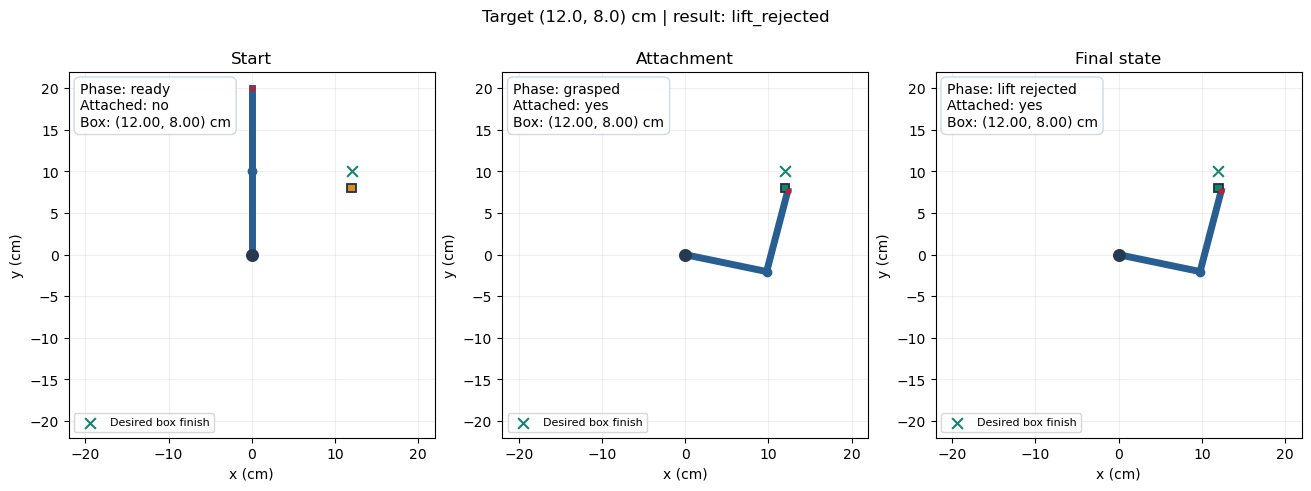

In [3]:
def draw_pickup_frame(ax, frame, summary, title=None):
    """Draw a precomputed frame; drawing never changes simulation state."""
    ax.clear()
    origin, elbow, hand = robot.forward_kinematics(*frame["angles"])
    points = np.array([origin, elbow, hand])
    ax.plot(points[:, 0], points[:, 1], "o-", color="#285e91", linewidth=5, markersize=6, markevery=[0, 1])
    ax.scatter(*origin, color="#263b50", s=70, zorder=4)
    ax.scatter(*hand, color="#b42338", s=12, zorder=5)
    box_center = np.asarray(frame["box_xy"])
    colour = "#16826c" if frame["attached"] else "#dc8b23"
    ax.add_patch(Rectangle(box_center - BOX_SIDE_CM / 2, BOX_SIDE_CM, BOX_SIDE_CM,
                           facecolor=colour, edgecolor="#193347", linewidth=1.3, zorder=3))
    ax.add_patch(Circle(summary["box_target_cm"], summary["grasp_tolerance_cm"],
                        fill=False, linestyle=":", edgecolor="#9b681b", linewidth=1))
    ax.scatter(*summary["desired_box_final_cm"], marker="x", color="#16826c", s=60, label="Desired box finish")
    ax.text(0.03, 0.97,
        f"Phase: {frame['phase'].replace('_', ' ')}\nAttached: {'yes' if frame['attached'] else 'no'}\n"
        f"Box: ({box_center[0]:.2f}, {box_center[1]:.2f}) cm",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cbd5e1", alpha=0.9))
    ax.set(xlim=(-22, 22), ylim=(-22, 22), aspect="equal", xlabel="x (cm)", ylabel="y (cm)",
           title=title or "ANN-driven simulated box pickup")
    ax.grid(alpha=0.2)
    ax.legend(loc="lower left", fontsize=8)

attached_frames = [frame for frame in pickup["frames"] if frame["attached"]]
middle_frame = attached_frames[0] if attached_frames else pickup["frames"][-1]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), layout="constrained")
for ax, frame, title in zip(axes, [pickup["frames"][0], middle_frame, pickup["frames"][-1]],
    ["Start", "Attachment" if attached_frames else "Pickup attempt", "Final state"]):
    draw_pickup_frame(ax, frame, pickup["summary"], title)
fig.suptitle(f"Target {BOX_TARGET_CM} cm | result: {pickup['summary']['status']}")
fig.savefig(simulation_directory / "pickup_snapshots.png", dpi=130)
plt.show()

## 6.4 Animate the pickup and lift

The GIF replays the precomputed joint motion, with a short pause at the start and finish. Changing drawing speed does not change the pickup checks. Animation uses Matplotlib's existing [FuncAnimation](https://matplotlib.org/stable/api/_as_gen/matplotlib.animation.FuncAnimation.html) and [PillowWriter](https://matplotlib.org/stable/api/_as_gen/matplotlib.animation.PillowWriter.html), with no new rendering framework.

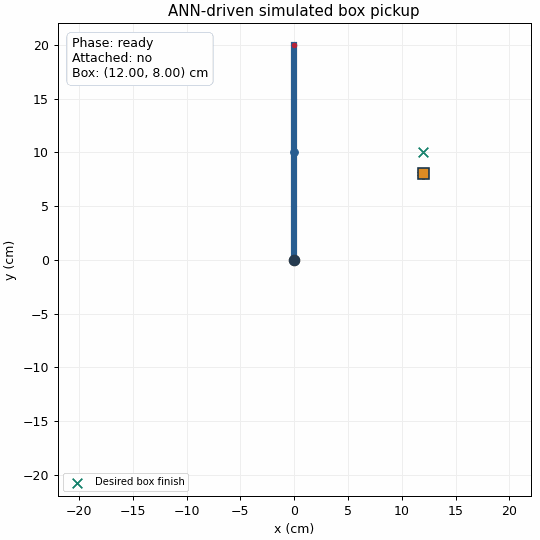

In [4]:
animation_frames = [pickup["frames"][0]] * 5 + pickup["frames"] + [pickup["frames"][-1]] * 15
fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")
def update_pickup_frame(index):
    draw_pickup_frame(ax, animation_frames[index], pickup["summary"])
animation = FuncAnimation(fig, update_pickup_frame, frames=len(animation_frames), interval=80, repeat=True)
gif_path = simulation_directory / "first_attempt.gif"
animation.save(gif_path, writer=PillowWriter(fps=12), dpi=90)
plt.close(fig)
display(Image(filename=str(gif_path)))

### A second reference scene, with the same checks

The first (12, 8) cm scene attached successfully but its proposed lift missed the 0.5 cm tolerance. We retained that rejected lift and then chose the familiar **(10, 10) cm** reference target as a separate demonstration. The start pose, 2 cm requested lift, model, and 0.5 cm tolerance are unchanged. This is a selected demonstration, not a new unbiased success-rate estimate; all three scene outcomes are saved.


status                                                                    success
success                                                                      True
box_target_cm                                                        [10.0, 10.0]
desired_box_final_cm                                                 [10.0, 12.0]
final_box_cm                                  [10.0966720781, 11.863227331200001]
approach_error_cm                                                        0.148097
final_box_error_cm                                                       0.167488
grasp_tolerance_cm                                                            0.5
requested_lift_cm                                                             2.0
actual_lift_cm                                                           1.863227
attached                                                                     True
message                         The box attached without snapping and reached ...
attachment_offse

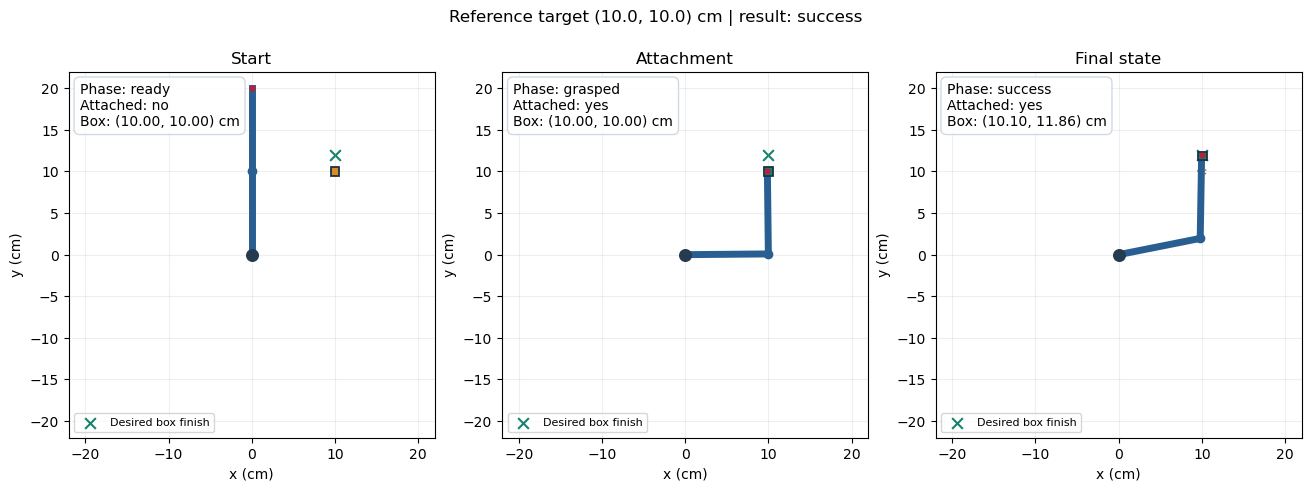

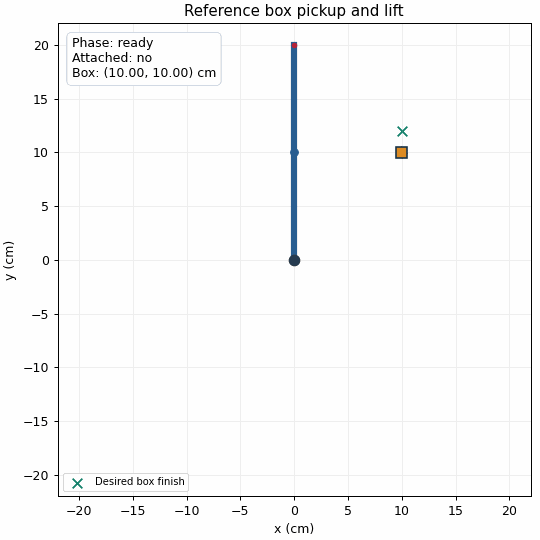

In [5]:
REFERENCE_BOX_CM = (10.0, 10.0)
reference_pickup = simulate_pickup(robot, predict_angles, REFERENCE_BOX_CM,
    start_angles=START_ANGLES_DEG, lift_cm=LIFT_CM,
    grasp_tolerance_cm=GRASP_TOLERANCE_CM, frames_per_move=FRAMES_PER_MOVE)
display(pd.Series(reference_pickup["summary"], name="Reference pickup result"))
reference_attached = [frame for frame in reference_pickup["frames"] if frame["attached"]]
reference_middle = reference_attached[0] if reference_attached else reference_pickup["frames"][-1]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), layout="constrained")
for ax, frame, title in zip(axes,
    [reference_pickup["frames"][0], reference_middle, reference_pickup["frames"][-1]],
    ["Start", "Attachment" if reference_attached else "Pickup attempt", "Final state"]):
    draw_pickup_frame(ax, frame, reference_pickup["summary"], title)
fig.suptitle(f"Reference target {REFERENCE_BOX_CM} cm | result: {reference_pickup['summary']['status']}")
fig.savefig(simulation_directory / "box_pickup_snapshots.png", dpi=130)
plt.show()

reference_frames = [reference_pickup["frames"][0]] * 5 + reference_pickup["frames"] + [reference_pickup["frames"][-1]] * 15
fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")
def update_reference_frame(index):
    draw_pickup_frame(ax, reference_frames[index], reference_pickup["summary"], "Reference box pickup and lift")
reference_animation = FuncAnimation(fig, update_reference_frame, frames=len(reference_frames), interval=80, repeat=True)
reference_gif = simulation_directory / "box_pickup.gif"
reference_animation.save(reference_gif, writer=PillowWriter(fps=12), dpi=90)
plt.close(fig)
display(Image(filename=str(reference_gif)))


## 6.5 Show an honest failed pickup

Reuse the worst target already identified in Step 5. This is a known failure demonstration, not a new test-set accuracy claim. The robot may move to its predicted pose if the angles are valid, but the box must remain where it started when the hand misses. A successful animation must never be created by snapping the box onto the hand after a bad prediction.

status                                                              pickup_missed
success                                                                     False
box_target_cm                                      [-8.2635182233, -9.8480775301]
desired_box_final_cm                          [-8.2635182233, -7.848077530099999]
final_box_cm                                       [-8.2635182233, -9.8480775301]
approach_error_cm                                                       32.764086
final_box_error_cm                                                            2.0
grasp_tolerance_cm                                                            0.5
requested_lift_cm                                                             2.0
actual_lift_cm                                                                0.0
attached                                                                    False
message                         The hand missed the grasp tolerance; the box s...
attachment_offse

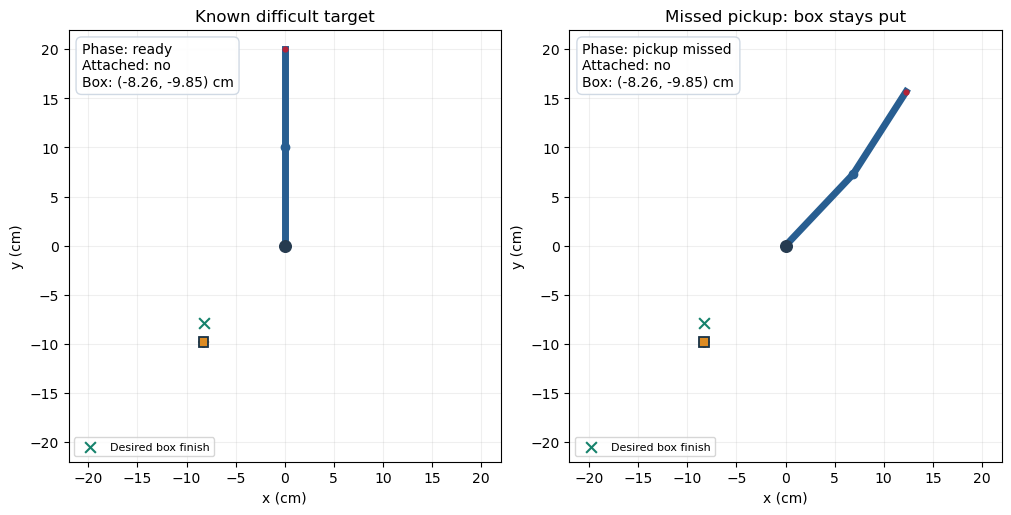

In [6]:
worst_case = json.loads(Path("evaluation/summary.json").read_text())["worst_case"]
failure_target = (worst_case["x_target"], worst_case["y_target"])
failed_pickup = simulate_pickup(robot, predict_angles, failure_target,
                                start_angles=START_ANGLES_DEG, lift_cm=LIFT_CM,
                                grasp_tolerance_cm=GRASP_TOLERANCE_CM, frames_per_move=FRAMES_PER_MOVE)
display(pd.Series(failed_pickup["summary"], name="Known failure demonstration"))
assert not failed_pickup["summary"]["success"]
assert not any(frame["attached"] for frame in failed_pickup["frames"])
for frame in failed_pickup["frames"]:
    np.testing.assert_array_equal(frame["box_xy"], failure_target)
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")
draw_pickup_frame(axes[0], failed_pickup["frames"][0], failed_pickup["summary"], "Known difficult target")
draw_pickup_frame(axes[1], failed_pickup["frames"][-1], failed_pickup["summary"], "Missed pickup: box stays put")
fig.savefig(simulation_directory / "failed_pickup.png", dpi=130)
plt.show()

## 6.6 Check state consistency and preserve the baseline

Check every frame's joint limits, box motion, and fixed attachment offset. Verify that the ordinary demo's final box position meets its reported status, then save a small report and confirm that all existing robot/model/data/evaluation artifacts are unchanged. Unit tests in `python/test_pickup_simulation.py` also cover missed pickup, invalid angles, rejected lift, and input validation with the existing robot model.

In [7]:
for run in [pickup, reference_pickup, failed_pickup]:
    offset = None
    for frame in run["frames"]:
        theta1, theta2 = frame["angles"]
        assert np.isfinite(frame["angles"]).all() and -90 <= theta1 <= 180 and -120 <= theta2 <= 120
        if frame["attached"]:
            if offset is None:
                offset = np.asarray(frame["box_xy"]) - np.asarray(frame["hand_xy"])
                np.testing.assert_allclose(frame["box_xy"], run["summary"]["box_target_cm"], atol=1e-10, rtol=0)
            np.testing.assert_allclose(np.asarray(frame["box_xy"]) - frame["hand_xy"], offset, atol=1e-10, rtol=0)
        else:
            np.testing.assert_array_equal(frame["box_xy"], run["summary"]["box_target_cm"])
    actual_final_error = np.linalg.norm(np.asarray(run["frames"][-1]["box_xy"]) - run["summary"]["desired_box_final_cm"])
    np.testing.assert_allclose(actual_final_error, run["summary"]["final_box_error_cm"], rtol=0, atol=1e-10)
    if run["summary"]["success"]:
        assert run["frames"][-1]["attached"] and actual_final_error <= GRASP_TOLERANCE_CM
        assert run["summary"]["actual_lift_cm"] > 0

for name, digest in source_hashes.items():
    assert sha256(Path(name).read_bytes()).hexdigest() == digest, f"Baseline changed: {name}"
report = {"first_attempt": pickup["summary"], "reference_demo": reference_pickup["summary"],
          "known_failure_demo": failed_pickup["summary"],
          "source_sha256": source_hashes, "gripper_model": "Ideal point attachment with fixed offset",
          "motion": "Joint interpolation for visualization only; no collision/trajectory planning",
          "model_retrained": False, "policy_changed": False,
          "scene_selection": "First (12,8) fixed before prediction; reference (10,10) added after its lift was rejected; all results retained"}
(simulation_directory / "pickup_results.json").write_text(json.dumps(report, indent=2, allow_nan=False) + "\n", encoding="utf-8")
print(json.dumps({"first_attempt": pickup["summary"], "reference_demo": reference_pickup["summary"], "known_failure_demo": failed_pickup["summary"]}, indent=2))
print("Frame checks passed; previous notebooks, datasets, model, and evaluation reports unchanged.")

{
  "first_attempt": {
    "status": "lift_rejected",
    "success": false,
    "box_target_cm": [
      12.0,
      8.0
    ],
    "desired_box_final_cm": [
      12.0,
      10.0
    ],
    "final_box_cm": [
      12.0,
      8.0
    ],
    "approach_error_cm": 0.483185956503058,
    "final_box_error_cm": 2.0,
    "grasp_tolerance_cm": 0.5,
    "requested_lift_cm": 2.0,
    "actual_lift_cm": 0.0,
    "attached": true,
    "message": "The predicted lift does not meet the box-position tolerance or raise the box; holding the grasp pose.",
    "attachment_offset_cm": [
      -0.32460684169999965,
      0.3579092998000002
    ],
    "lift_target_cm": [
      12.3246068417,
      9.6420907002
    ],
    "lift_prediction_box_error_cm": 0.6217266716879176
  },
  "reference_demo": {
    "status": "success",
    "success": true,
    "box_target_cm": [
      10.0,
      10.0
    ],
    "desired_box_final_cm": [
      10.0,
      12.0
    ],
    "final_box_cm": [
      10.0966720781,
      11.86

### Recorded outcomes

| Scene | Approach | Lift outcome |
|---|---|---|
| First (12, 8) cm | Attached; 0.483 cm error | Proposed lift error 0.622 cm exceeds tolerance; held at initial height |
| Reference (10, 10) cm | Attached; 0.148 cm error | Lift completed; box rose 1.863 cm and finished 0.167 cm from (10, 12) cm |
| Known worst target | Missed by 32.764 cm | No attachment or box movement |

All scenes use the same 0.5 cm tolerance and unchanged ANN. The reference outcome demonstrates a successful simplified lift; it does not erase the first rejected lift or the known failure.


## Review checkpoint

This is a first geometric pickup-and-lift demonstration with explicit success/failure states. A successful trial demonstrates this one requested motion under the simplified assumptions; it does not establish general grasping reliability. Step 5's large ANN errors remain present.

The box remains attached at the end. Table interaction, obstacle-aware trajectories, physical gripper mechanics, transport/release, and a full pick-and-place cycle remain later steps. Review this simulation before proceeding to Step 7.